
Mn_R1s(r) =
+245.1936 * exp(-25.6998 r)
+166.9334 * r * exp(-21.8567 r)
+0.1252 * r * exp(-10.7524 r)
+672.9950 * r^2 * exp(-31.6095 r)
-0.0586 * r^2 * exp(-7.9533 r)
-0.0115 * r^2 * exp(-5.4792 r)
+0.0003 * r^2 * exp(-3.6809 r)
+2.6164 * r^3 * exp(-12.6273 r)
-0.0000 * r^3 * exp(-2.1701 r)
+0.0000 * r^3 * exp(-1.3884 r)
-0.0000 * r^3 * exp(-0.9204 r)

Mn_R2s(r) =
-73.9493 * exp(-25.6998 r)
-484.4939 * r * exp(-21.8567 r)
+434.8475 * r * exp(-10.7524 r)
-58.4725 * r^2 * exp(-31.6095 r)
+59.8528 * r^2 * exp(-7.9533 r)
-1.1694 * r^2 * exp(-5.4792 r)
+0.1229 * r^2 * exp(-3.6809 r)
+986.2628 * r^3 * exp(-12.6273 r)
-0.0013 * r^3 * exp(-2.1701 r)
+0.0001 * r^3 * exp(-1.3884 r)
-0.0000 * r^3 * exp(-0.9204 r)

Mn_R3s(r) =
+27.1858 * exp(-25.6998 r)
+206.2123 * r * exp(-21.8567 r)
-188.4061 * r * exp(-10.7524 r)
+66.7829 * r^2 * exp(-31.6095 r)
-69.6414 * r^2 * exp(-7.9533 r)
+100.5424 * r^2 * exp(-5.4792 r)
+24.0668 * r^2 * exp(-3.6809 r)
-1038.7741 * r^3 * exp(-12.6273 r)
+0.0304 * r^3 * ex

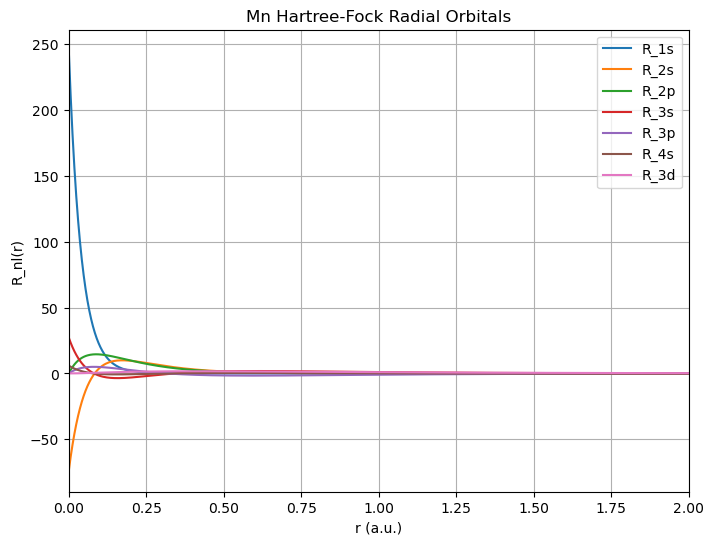

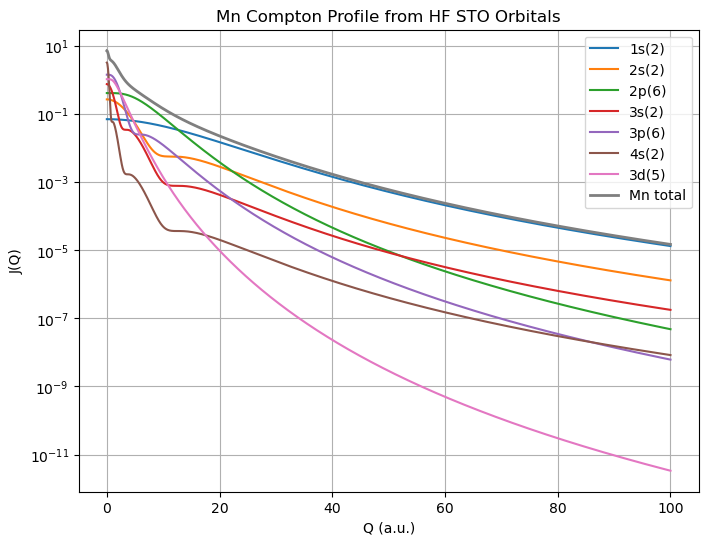

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Manganese Hartree-Fock STO data
# Mn: 1s2 2s2 2p6 3s2 3p6 3d5 4s2
# Ground term: 4s
# Format: (n_j, Z_j, C_j)
# =====================================================

# =====================================================
# 1s orbital
# =====================================================

manganese_1s = [
    (1, 25.6998,  0.940989),
    (2, 21.8567,  0.064731),
    (2, 10.7524,  0.000286),
    (3, 31.6095,  0.008989),
    (3,  7.9533, -0.000098),
    (3,  5.4792, -0.000071),
    (3,  3.6809,  0.000007),
    (4, 12.6273,  0.000257),
    (4,  2.1701, -0.000006),
    (4,  1.3884,  0.000004),
    (4,  0.9204, -0.000001),
]


# =====================================================
# 2s orbital
# =====================================================

manganese_2s = [
    (1, 25.6998, -0.283798),
    (2, 21.8567, -0.187870),
    (2, 10.7524,  0.993354),
    (3, 31.6095, -0.000781),
    (3,  7.9533,  0.100053),
    (3,  5.4792, -0.007203),
    (3,  3.6809,  0.003047),
    (4, 12.6273,  0.096877),
    (4,  2.1701, -0.000357),
    (4,  1.3884,  0.000212),
    (4,  0.9204, -0.000071),
]


# =====================================================
# 3s orbital
# =====================================================

manganese_3s = [
    (1, 25.6998,  0.104332),
    (2, 21.8567,  0.079962),
    (2, 10.7524, -0.430390),
    (3, 31.6095,  0.000892),
    (3,  7.9533, -0.116416),
    (3,  5.4792,  0.619299),
    (3,  3.6809,  0.596542),
    (4, 12.6273, -0.102035),
    (4,  2.1701,  0.008247),
    (4,  1.3884, -0.002062),
    (4,  0.9204,  0.000527),
]


# =====================================================
# 4s orbital
# =====================================================

manganese_4s = [
    (1, 25.6998,  0.022617),
    (2, 21.8567,  0.017628),
    (2, 10.7524, -0.094991),
    (3, 31.6095,  0.000191),
    (3,  7.9533, -0.031656),
    (3,  5.4792,  0.167891),
    (3,  3.6809,  0.138100),
    (4, 12.6273, -0.024434),
    (4,  2.1701, -0.272491),
    (4,  1.3884, -0.538366),
    (4,  0.9204, -0.315216),
]


# =====================================================
# 2p orbital
# =====================================================

manganese_2p = [
    (2, 39.7636,  0.000680),
    (2, 15.5794,  0.329684),
    (2,  8.2726,  0.425128),
    (2,  3.9144,  0.005727),
    (3, 12.5884,  0.292622),
    (3,  3.2243, -0.000552),
    (3,  2.1059,  0.000178),
]


# =====================================================
# 3p orbital
# =====================================================

manganese_3p = [
    (2, 39.7636,  0.000175),
    (2, 15.5794,  0.070131),
    (2,  8.2726,  0.510669),
    (2,  3.9144, -0.801936),
    (3, 12.5884,  0.015885),
    (3,  3.2243, -0.422222),
    (3,  2.1059, -0.044967),
]


# =====================================================
# 3d orbital
# =====================================================

manganese_3d = [
    (3, 12.1103, 0.018122),
    (3,  6.2285, 0.214643),
    (3,  3.7645, 0.417697),
    (3,  2.2778, 0.384751),
    (3,  1.4273, 0.120919),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Iron radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, manganese_1s)
R2s = R_nl(r, manganese_2s)
R3s = R_nl(r, manganese_3s)
R4s = R_nl(r, manganese_4s)
R2p = R_nl(r, manganese_2p)
R3p = R_nl(r, manganese_3p)
R3d = R_nl(r, manganese_3d)

print_R_formula(manganese_1s, "Mn_R1s")
print_R_formula(manganese_2s, "Mn_R2s")
print_R_formula(manganese_3s, "Mn_R3s")
print_R_formula(manganese_4s, "Mn_R4s")
print_R_formula(manganese_2p, "Mn_R2p")
print_R_formula(manganese_3p, "Mn_R3p")
print_R_formula(manganese_3d, "Mn_R3d")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))


# Mn has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(5) 4s(2) 
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 5*J_3d + 2*J_4s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_4s(2)": J_4s,
    "J_3d(5)":J_3d,
    "J_total_Mn": J_total
    })
print(table)
table.to_csv("Mn_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Mn Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 5*J_3d, label="3d(5)")
plt.plot(Q, J_total, label="Mn total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Mn Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()